In [3]:
import h5py
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

with h5py.File("alldata.hdf5", "r") as f:
    dat = {k: f[k][:] for k in f.keys()}

import scipy.spatial

nsamples = dat["trap_centers"].shape[0]
N = dat["trap_centers"].shape[1]
dat["rij"] = np.zeros((nsamples, N, N))
dat["rx_ij"] = np.zeros((nsamples, N, N))
dat["ry_ij"] = np.zeros((nsamples, N, N))
dat["dV_ij"] = np.zeros((nsamples, N, N))

for i, r in enumerate(dat["trap_centers"]):
    dat["rij"][i, :, :] = scipy.spatial.distance_matrix(r, r)
    rx = r[:, [0]]
    ry = r[:, [1]]
    dat["rx_ij"][i, :, :] = rx - rx.T
    dat["ry_ij"][i, :, :] = ry - ry.T
    v = dat["V_offset"][i, :][:, None]
    dat["dV_ij"][i, :, :] = v - v.T

import sys
import os

module_path = os.path.abspath(os.path.join("../../src/"))
if module_path not in sys.path:
    sys.path.append(module_path)

from HubbardTweezer.Hubbard.lattice import sqr_lattice

# Pick n.n. distances
nodes, links, node_idx_pair = sqr_lattice(np.array([4, 4]))
nnr = dat["rij"][:, links[:, 0], links[:, 1]]
nnt = dat["t_ij"][:, links[:, 0], links[:, 1]]

# Filter bad samples
# mask = dat["wf_cost"] < 6e-5
mask = np.min(dat["U_i"], axis=1) > 0.8
nmask = np.sum(mask)
print(len(dat["t_ij"]))
print(nmask)

3001
1190


`alpha` visibility threshold is `2e-3`.

# Analysis

## Coordinate chart

| 1 | 2 | 3 | 4 |
|---|---|---|---|
| 5 | 6 | 7 | 8 |
| 9 | 10 | 11 | 12 |
| 13 | 14 | 15 | 16 |

## Distance effect

(-0.05, 0.7)

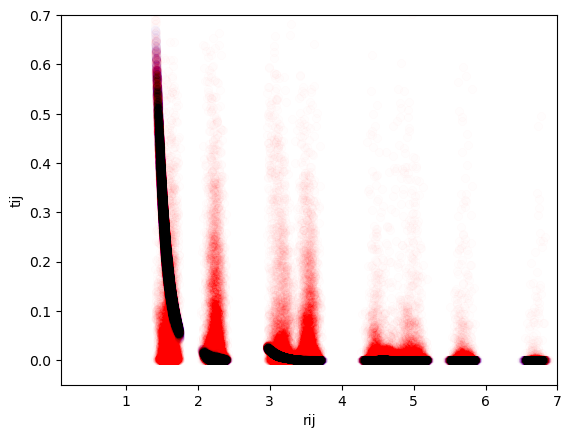

In [8]:
plt.scatter(
    dat["rij"][~mask].flatten(), dat["t_ij"][~mask].flatten(), color="r", alpha=2e-3
)
plt.scatter(
    dat["rij"][mask].flatten(), dat["t_ij"][mask].flatten(), color="blue", alpha=2e-3
)
plt.xlabel("rij")
plt.ylabel("tij")
plt.xlim(0.1, 7)
plt.ylim(-0.05, 0.7)

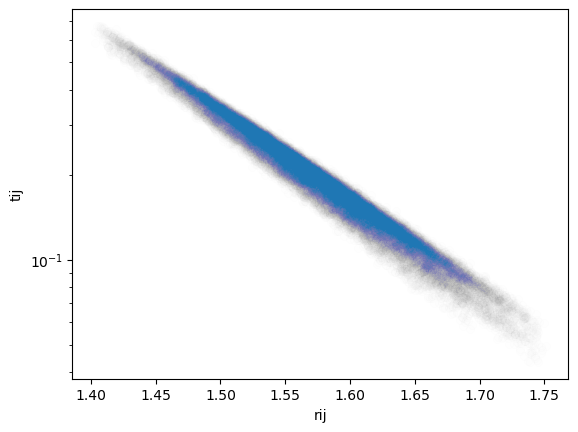

In [11]:
plt.scatter(nnr[mask].flatten(), nnt[mask].flatten(), alpha=2e-3)
plt.xlabel("rij")
plt.ylabel("tij")
plt.yscale("log")

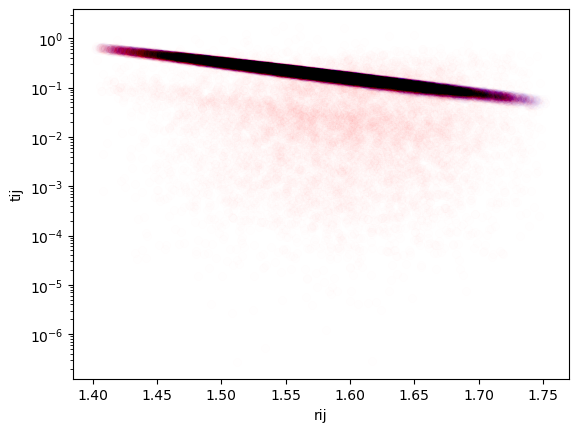

In [16]:
plt.scatter(nnr[~mask].flatten(), nnt[~mask].flatten(), color="r", alpha=5e-3)
plt.scatter(nnr[mask].flatten(), nnt[mask].flatten(), color="b", alpha=5e-3)

plt.xlabel("rij")
plt.ylabel("tij")
plt.yscale("log")

The above plots show a clear $e^{-r}$ decay instead of $e^{-r^2}$ by the Gaussian approximation of the Wannier function.

This is a clear sign that the Gaussian approximation is not valid for this system.

## Position effect

### t_12 vs t_15

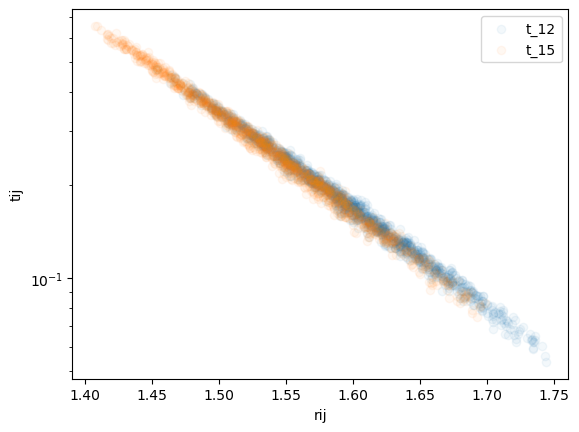

In [19]:
l1 = 0
l2 = 1
plt.scatter(
    dat["rij"][mask, l1, l2].flatten(),
    dat["t_ij"][mask, l1, l2].flatten(),
    alpha=5e-2,
    label=f"t_{l1+1}{l2+1}",
)
l1 = 0
l2 = 4
plt.scatter(
    dat["rij"][mask, l1, l2].flatten(),
    dat["t_ij"][mask, l1, l2].flatten(),
    alpha=5e-2,
    label=f"t_{l1+1}{l2+1}",
)
plt.legend()
plt.xlabel("rij")
plt.ylabel("tij")
plt.yscale("log")

### t_12 vs t_26

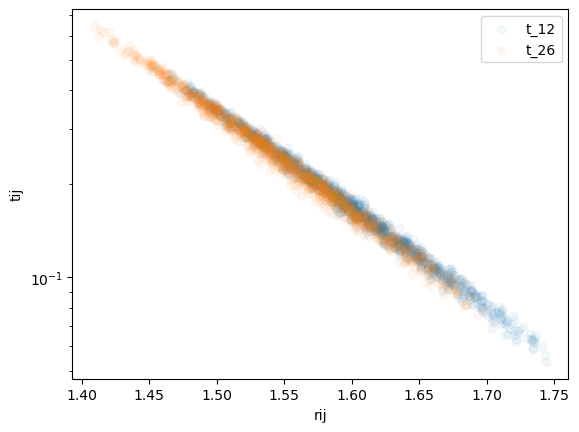

In [20]:
l1 = 0
l2 = 1
plt.scatter(
    dat["rij"][mask, l1, l2].flatten(),
    dat["t_ij"][mask, l1, l2].flatten(),
    alpha=5e-2,
    label=f"t_{l1+1}{l2+1}",
)
l1 = 1
l2 = 5
plt.scatter(
    dat["rij"][mask, l1, l2].flatten(),
    dat["t_ij"][mask, l1, l2].flatten(),
    alpha=5e-2,
    label=f"t_{l1+1}{l2+1}",
)
plt.legend()
plt.xlabel("rij")
plt.ylabel("tij")
plt.yscale("log")

### t_56 vs t_59

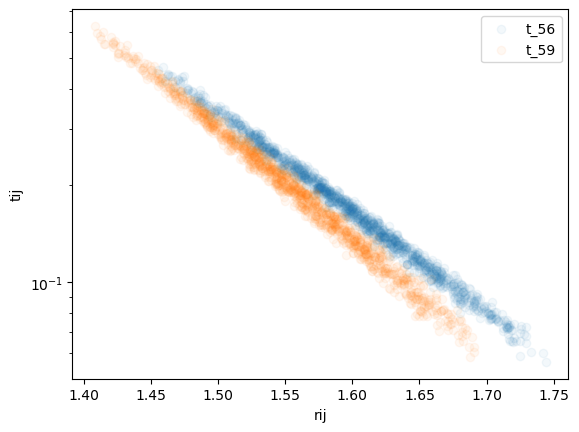

In [21]:
l1 = 4
l2 = 5
plt.scatter(
    dat["rij"][mask, l1, l2].flatten(),
    dat["t_ij"][mask, l1, l2].flatten(),
    alpha=5e-2,
    label=f"t_{l1+1}{l2+1}",
)
l1 = 4
l2 = 8
plt.scatter(
    dat["rij"][mask, l1, l2].flatten(),
    dat["t_ij"][mask, l1, l2].flatten(),
    alpha=5e-2,
    label=f"t_{l1+1}{l2+1}",
)
plt.legend()
plt.xlabel("rij")
plt.ylabel("tij")
plt.yscale("log")

### t_67 vs t_6,10

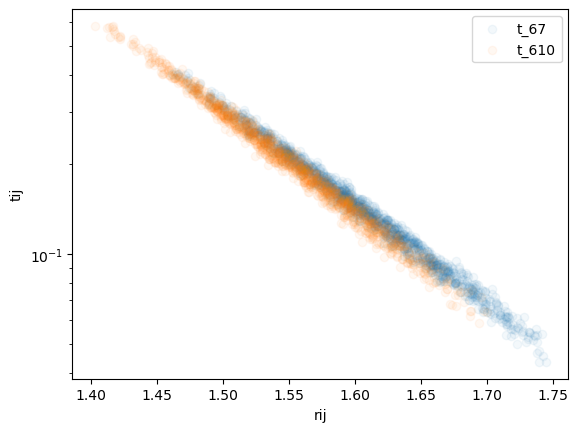

In [22]:
l1 = 5
l2 = 6
plt.scatter(
    dat["rij"][mask, l1, l2].flatten(),
    dat["t_ij"][mask, l1, l2].flatten(),
    alpha=5e-2,
    label=f"t_{l1+1}{l2+1}",
)
l1 = 5
l2 = 9
plt.scatter(
    dat["rij"][mask, l1, l2].flatten(),
    dat["t_ij"][mask, l1, l2].flatten(),
    alpha=5e-2,
    label=f"t_{l1+1}{l2+1}",
)
plt.legend()
plt.xlabel("rij")
plt.ylabel("tij")
plt.yscale("log")

## boundary effect

### horizontal

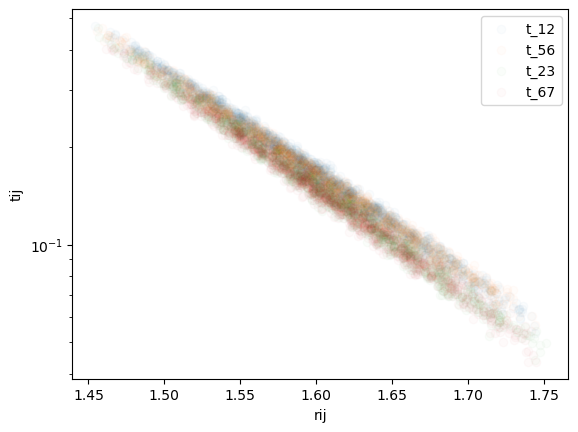

In [25]:
l1 = 0
l2 = 1
plt.scatter(
    dat["rij"][mask, l1, l2].flatten(),
    dat["t_ij"][mask, l1, l2].flatten(),
    alpha=2e-2,
    label=f"t_{l1+1}{l2+1}",
)
l1 = 4
l2 = 5
plt.scatter(
    dat["rij"][mask, l1, l2].flatten(),
    dat["t_ij"][mask, l1, l2].flatten(),
    alpha=2e-2,
    label=f"t_{l1+ 1}{l2+1}",
)
l1 = 1
l2 = 2
plt.scatter(
    dat["rij"][mask, l1, l2].flatten(),
    dat["t_ij"][mask, l1, l2].flatten(),
    alpha=2e-2,
    label=f"t_{l1+ 1}{l2+1}",
)
l1 = 5
l2 = 6
plt.scatter(
    dat["rij"][mask, l1, l2].flatten(),
    dat["t_ij"][mask, l1, l2].flatten(),
    alpha=2e-2,
    label=f"t_{l1+ 1}{l2+1}",
)
plt.legend()
plt.xlabel("rij")
plt.ylabel("tij")
plt.yscale("log")

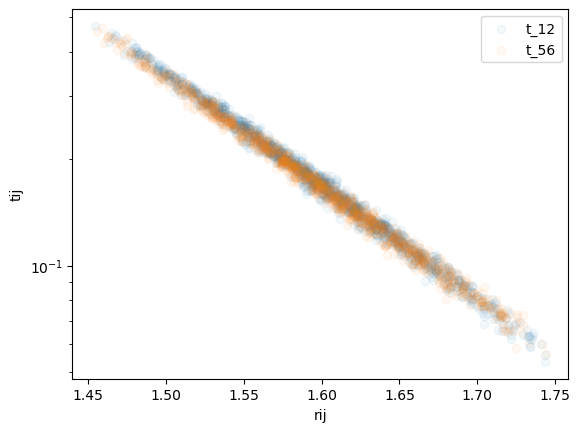

In [27]:
l1 = 0
l2 = 1
plt.scatter(
    dat["rij"][mask, l1, l2].flatten(),
    dat["t_ij"][mask, l1, l2].flatten(),
    alpha=5e-2,
    label=f"t_{l1+1}{l2+1}",
)
l1 = 4
l2 = 5
plt.scatter(
    dat["rij"][mask, l1, l2].flatten(),
    dat["t_ij"][mask, l1, l2].flatten(),
    alpha=5e-2,
    label=f"t_{l1+ 1}{l2+1}",
)
plt.legend()
plt.xlabel("rij")
plt.ylabel("tij")
plt.yscale("log")

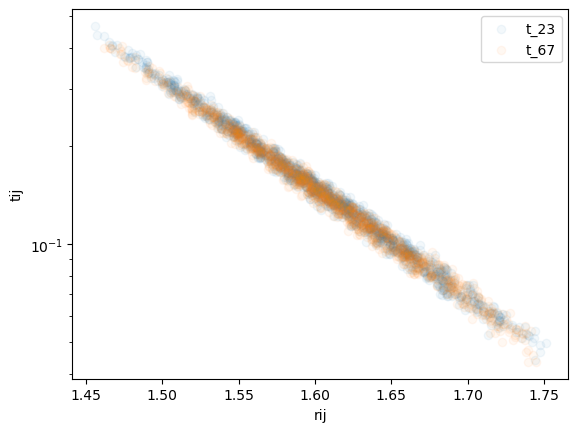

In [28]:
l1 = 1
l2 = 2
plt.scatter(
    dat["rij"][mask, l1, l2].flatten(),
    dat["t_ij"][mask, l1, l2].flatten(),
    alpha=5e-2,
    label=f"t_{l1+ 1}{l2+1}",
)
l1 = 5
l2 = 6
plt.scatter(
    dat["rij"][mask, l1, l2].flatten(),
    dat["t_ij"][mask, l1, l2].flatten(),
    alpha=5e-2,
    label=f"t_{l1+ 1}{l2+1}",
)
plt.legend()
plt.xlabel("rij")
plt.ylabel("tij")
plt.yscale("log")

### vertical

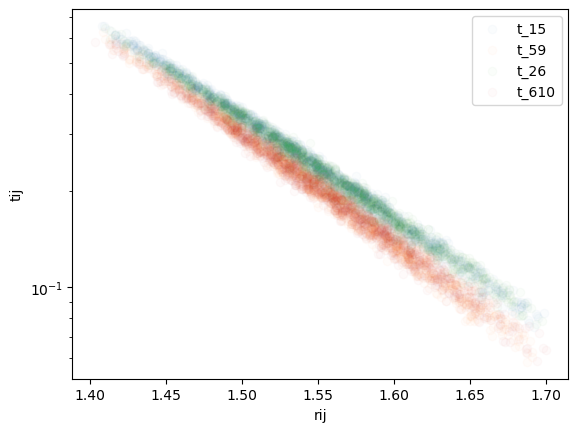

In [29]:
l1 = 0
l2 = 4
plt.scatter(
    dat["rij"][mask, l1, l2].flatten(),
    dat["t_ij"][mask, l1, l2].flatten(),
    alpha=2e-2,
    label=f"t_{l1+1}{l2+1}",
)
l1 = 4
l2 = 8
plt.scatter(
    dat["rij"][mask, l1, l2].flatten(),
    dat["t_ij"][mask, l1, l2].flatten(),
    alpha=2e-2,
    label=f"t_{l1+ 1}{l2+1}",
)
l1 = 1
l2 = 5
plt.scatter(
    dat["rij"][mask, l1, l2].flatten(),
    dat["t_ij"][mask, l1, l2].flatten(),
    alpha=2e-2,
    label=f"t_{l1+ 1}{l2+1}",
)
l1 = 5
l2 = 9
plt.scatter(
    dat["rij"][mask, l1, l2].flatten(),
    dat["t_ij"][mask, l1, l2].flatten(),
    alpha=2e-2,
    label=f"t_{l1+ 1}{l2+1}",
)
plt.legend()
plt.xlabel("rij")
plt.ylabel("tij")
plt.yscale("log")

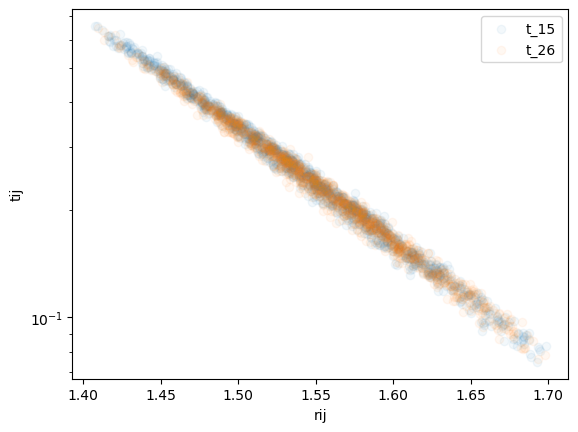

In [30]:
l1 = 0
l2 = 4
plt.scatter(
    dat["rij"][mask, l1, l2].flatten(),
    dat["t_ij"][mask, l1, l2].flatten(),
    alpha=5e-2,
    label=f"t_{l1+1}{l2+1}",
)
l1 = 1
l2 = 5
plt.scatter(
    dat["rij"][mask, l1, l2].flatten(),
    dat["t_ij"][mask, l1, l2].flatten(),
    alpha=5e-2,
    label=f"t_{l1+ 1}{l2+1}",
)
plt.legend()
plt.xlabel("rij")
plt.ylabel("tij")
plt.yscale("log")

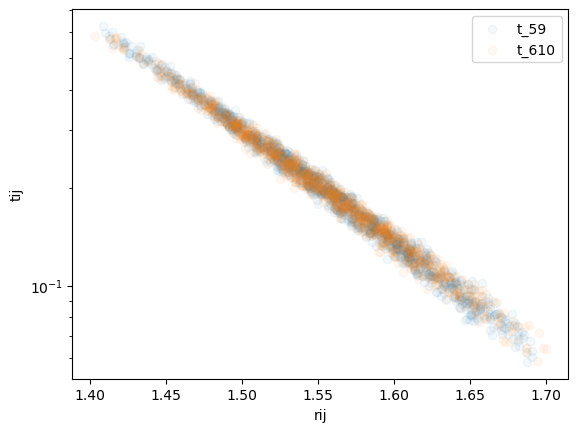

In [31]:
l1 = 4
l2 = 8
plt.scatter(
    dat["rij"][mask, l1, l2].flatten(),
    dat["t_ij"][mask, l1, l2].flatten(),
    alpha=5e-2,
    label=f"t_{l1+ 1}{l2+1}",
)
l1 = 5
l2 = 9
plt.scatter(
    dat["rij"][mask, l1, l2].flatten(),
    dat["t_ij"][mask, l1, l2].flatten(),
    alpha=5e-2,
    label=f"t_{l1+ 1}{l2+1}",
)
plt.legend()
plt.xlabel("rij")
plt.ylabel("tij")
plt.yscale("log")

## Summary

n.n. tunneling can be classified as two types depending on which bond they are at. This is independent of direction. The two types are:

1. Type 1: t_12, t_15, t_56, t_26
2. Type 2: t_23, t_67, t_59, t_6,10

How to characterize the two types?
1. The difference is only the environment on the direction of the bond.
2. Try add the neighboring number of atoms along the bond direction.

# Fit the data

## Single factor rij

NOTE: MSELoss is the same as cost function usually used in regression.

Sort the data.

In [32]:
X = nnr[mask].flatten()
arg = np.argsort(X)
X = X[arg]
Y = nnt[mask].flatten()
Y = Y[arg]

### Exponential fitting

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.autograd import Variable


# Custom Model for Exponential Fitting
class ExponentialModel(nn.Module):
    def __init__(self):
        super(ExponentialModel, self).__init__()
        self.a = nn.Parameter(torch.randn(()))  # Initialize the 'a' parameter
        self.b = nn.Parameter(torch.randn(()))  # Initialize the 'b' parameter

    def forward(self, x):
        return self.b * torch.exp(self.a * x)


# Convert data to torch tensors
X_torch = torch.tensor(X, dtype=torch.float64)
Y_torch = torch.tensor(Y, dtype=torch.float64)

# Initialize the model
model = ExponentialModel()


def criterion(outputs, targets):
    # Define the MSE loss
    mse_loss = nn.MSELoss()

    # Inside your training loop
    loss = mse_loss(outputs, targets) / (
        torch.var(targets) if torch.var(targets) != 0 else 1.0
    )
    return loss


def regression(X, Y, model: nn.Module, maxiter=1000, tol=1e-9):
    # optimizer = optim.SGD(model.parameters(), lr=0.01)
    # Using L-BFGS Optimizer
    optimizer = optim.LBFGS(
        model.parameters(),
        lr=0.005,
        max_iter=maxiter,
        tolerance_grad=tol * 1e2,
        tolerance_change=tol,
    )

    # Training Loop
    loss_old = torch.inf
    loss_new = torch.inf

    def closure():
        optimizer.zero_grad()
        outputs = model(X)
        loss = criterion(outputs, Y)
        loss.backward()
        return loss

    # Training Loop
    for epoch in range(maxiter):  # Number of epochs
        if loss_old - loss_new < tol:
            break
        loss_old = loss_new

        optimizer.step(closure)
        loss = closure().item()
        loss_new = loss
        # # Forward pass
        # outputs = model(X_torch)
        # loss = criterion(outputs, Y_torch)
        # loss_new = loss.item()
        if epoch % 1 == 0:
            print(f"Epoch [{epoch+1}/{maxiter}], Loss: {loss_new:.4f}")
        # # Backward and optimize
        # optimizer.zero_grad()
        # loss.backward()
        # optimizer.step()

    print(f"Final Loss: {loss_new:.4f}")
    return model


def r_squared(X, Y, model: nn.Module):
    # Step 1: Predict Outputs
    model.eval()  # Set the model to evaluation mode
    with torch.no_grad():
        predictions = model(X)

    # Step 2: Calculate SST
    sst = torch.std(Y) ** 2
    # Step 3: Calculate SSR
    ssr = torch.mean((Y - predictions) ** 2)

    # Step 4: Compute R^2
    r2 = 1 - ssr / sst
    return r2.item()


model = regression(X_torch, Y_torch, model)
r2 = r_squared(X_torch, Y_torch, model)

a = model.a.item()
b = model.b.item()

print(f"Exponential model: Y = {b} * exp({a} * X)")
print(f"R^2 Score: {r2}")

Epoch [1/1000], Loss: 0.5307
Epoch [2/1000], Loss: 0.1636
Epoch [3/1000], Loss: 0.0339
Epoch [4/1000], Loss: 0.0228
Epoch [5/1000], Loss: 0.0228
Epoch [6/1000], Loss: 0.0228
Epoch [7/1000], Loss: 0.0228
Final Loss: 0.0228
Exponential model: Y = 19959.87109375 * exp(-7.3415398597717285 * X)
R^2 Score: 0.9771669062321128


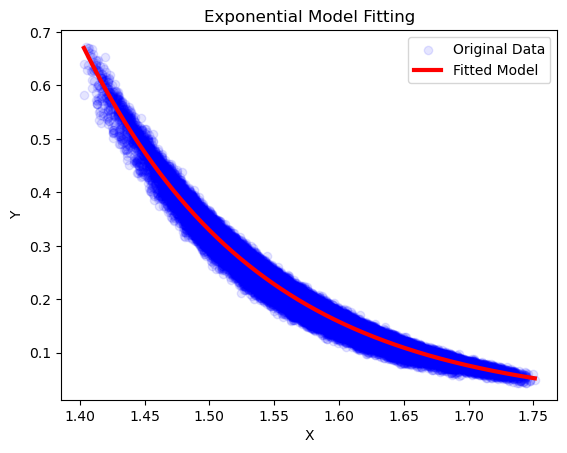

In [4]:
import matplotlib.pyplot as plt

# Generate predictions from the model
with torch.no_grad():  # We don't need gradients for prediction
    predicted = model(X_torch).numpy()

# Plotting the original data
plt.scatter(X, Y, color="blue", label="Original Data", alpha=0.1)

# Plotting the model's predictions
plt.plot(X, predicted, color="red", label="Fitted Model", linewidth=3)

# Adding labels and title
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Exponential Model Fitting")
plt.legend()
# plt.yscale("log")

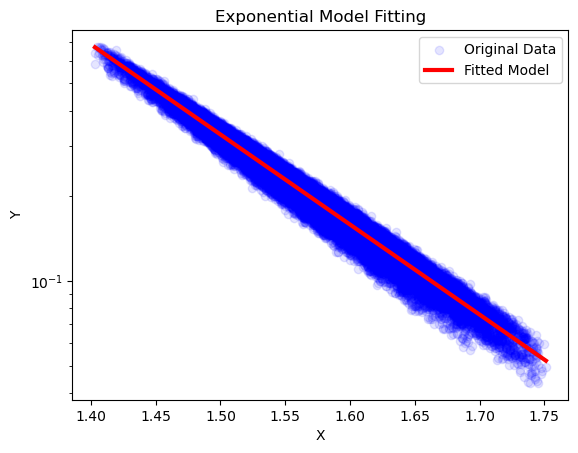

In [5]:
import matplotlib.pyplot as plt

# Generate predictions from the model
with torch.no_grad():  # We don't need gradients for prediction
    predicted = model(X_torch).numpy()

# Plotting the original data
plt.scatter(X, Y, color="blue", label="Original Data", alpha=0.1)

# Plotting the model's predictions
plt.plot(X, predicted, color="red", label="Fitted Model", linewidth=3)

# Adding labels and title
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Exponential Model Fitting")
plt.legend()
plt.yscale("log")

Text(0.5, 1.0, 'Histogram of Residuals')

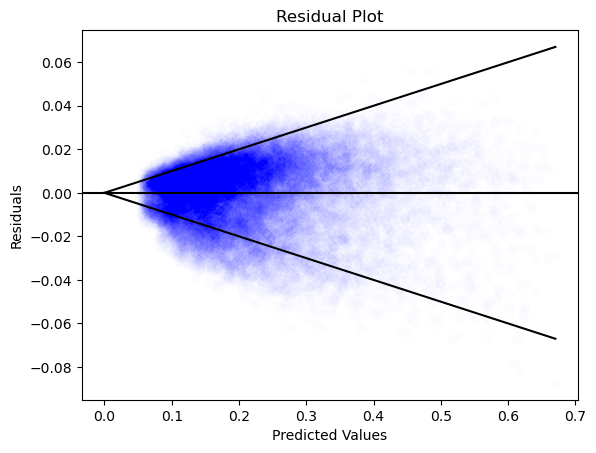

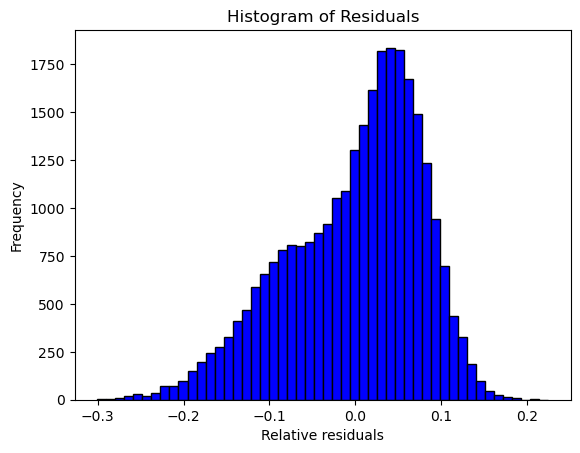

In [6]:
import matplotlib.pyplot as plt


# Function to calculate residuals
def calculate_residuals(model, X, Y):
    model.eval()  # Set the model to evaluation mode
    with torch.no_grad():
        predictions = model(X)
    residuals = Y - predictions
    return predictions, residuals


# Calculate residuals
predictions, residuals = calculate_residuals(model, X_torch, Y_torch)

# Convert to numpy for plotting
predictions_np = predictions.numpy().flatten()
residuals_np = residuals.numpy().flatten()

# Plotting residuals
plt.figure()
plt.scatter(predictions_np, residuals_np, color="blue", alpha=8e-3)
plt.axhline(y=0, color="k", linestyle="-")
x = np.linspace(0, np.max(predictions_np), 100)
plt.plot(x, 0.1 * x, color="k")
plt.plot(x, -0.1 * x, color="k")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")

# Optional: Histogram of Residuals
plt.figure()
plt.hist(residuals_np / predictions_np, bins=50, color="blue", edgecolor="black")
plt.xlabel("Relative residuals")
plt.ylabel("Frequency")
plt.title("Histogram of Residuals")

There is clearly 2 shopulders on both hand sides.

### Linear fitting on log scale

In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.autograd import Variable


class LinearModel(nn.Module):
    def __init__(self):
        super(LinearModel, self).__init__()
        self.a = nn.Parameter(-2 * torch.ones(1))  # Initialize the 'a' parameter
        self.b = nn.Parameter(2 * torch.ones(1))  # Initialize the 'b' parameter

    def forward(self, x):
        return self.a * x + self.b


# Convert data to torch tensors
X_torch = torch.tensor(X, dtype=torch.float32)
Y_torch = torch.tensor(Y, dtype=torch.float32)
# Assuming X and Y are your data arrays
Y_log = torch.log(Y_torch)  # Take the logarithm of Y

# Initialize the model
model = LinearModel()


def criterion(outputs, targets):
    # Restore original scale of Y
    targets = torch.exp(targets)
    outputs = torch.exp(outputs)

    # Define the MSE loss
    mse_loss = nn.MSELoss()

    # Inside your training loop
    loss = mse_loss(outputs, targets) / (
        torch.var(targets) if torch.var(targets) != 0 else 1.0
    )
    return loss


def regression(X, Y, model: nn.Module, maxiter=1000, tol=1e-9):
    # optimizer = optim.SGD(model.parameters(), lr=0.01)
    # Using L-BFGS Optimizer
    optimizer = optim.LBFGS(
        model.parameters(),
        lr=0.005,
        max_iter=maxiter,
        tolerance_grad=tol * 1e2,
        tolerance_change=tol,
    )

    # Training Loop
    loss_old = torch.inf
    loss_new = torch.inf

    def closure():
        optimizer.zero_grad()
        outputs = model(X)
        loss = criterion(outputs, Y)
        loss.backward()
        return loss

    # Training Loop
    for epoch in range(maxiter):  # Number of epochs
        if loss_old - loss_new < tol:
            break
        loss_old = loss_new

        optimizer.step(closure)
        loss = closure().item()
        loss_new = loss
        # # Forward pass
        # outputs = model(X_torch)
        # loss = criterion(outputs, Y_torch)
        # loss_new = loss.item()
        if epoch % 1 == 0:
            print(f"Epoch [{epoch+1}/{maxiter}], Loss: {loss_new:.4f}")
        # # Backward and optimize
        # optimizer.zero_grad()
        # loss.backward()
        # optimizer.step()

    print(f"Final Loss: {loss_new:.4f}")
    return model


def r_squared(X, Y, model: nn.Module):
    # Step 1: Predict Outputs
    model.eval()  # Set the model to evaluation mode
    with torch.no_grad():
        predictions = model(X)

    # Step 2: Calculate SST
    sst = torch.std(Y) ** 2
    # Step 3: Calculate SSR
    ssr = torch.mean((Y - predictions) ** 2)

    # Step 4: Compute R^2
    r2 = 1 - ssr / sst
    return r2.item()


model = regression(X_torch, Y_log, model)
r2 = r_squared(X_torch, Y_log, model)

a = model.a.item()
b = np.exp(model.b.item())

print(f"Exponential model: Y = {b} * exp({a} * X)")
print(f"R^2 Score: {r2}")

Epoch [1/1000], Loss: 0.0235
Epoch [2/1000], Loss: 0.0228
Epoch [3/1000], Loss: 0.0228
Epoch [4/1000], Loss: 0.0228
Epoch [5/1000], Loss: 0.0228
Epoch [6/1000], Loss: 0.0228
Epoch [7/1000], Loss: 0.0228
Epoch [8/1000], Loss: 0.0228
Epoch [9/1000], Loss: 0.0228
Epoch [10/1000], Loss: 0.0228
Epoch [11/1000], Loss: 0.0228
Epoch [12/1000], Loss: 0.0228
Epoch [13/1000], Loss: 0.0228
Epoch [14/1000], Loss: 0.0228
Epoch [15/1000], Loss: 0.0228
Epoch [16/1000], Loss: 0.0228
Epoch [17/1000], Loss: 0.0228
Final Loss: 0.0228
Exponential model: Y = 19926.941855504738 * exp(-7.34044075012207 * X)
R^2 Score: 0.9720325469970703


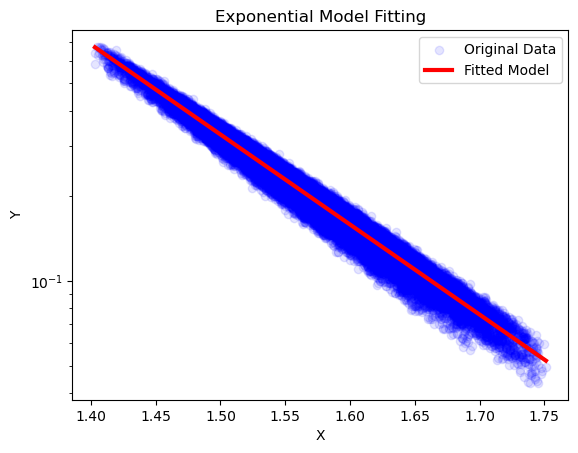

In [8]:
import matplotlib.pyplot as plt

# Generate predictions from the model
with torch.no_grad():  # We don't need gradients for prediction
    predicted = torch.exp(model(X_torch)).numpy()

# Plotting the original data
plt.scatter(X, Y, color="blue", label="Original Data", alpha=0.1)

# Plotting the model's predictions
plt.plot(X, predicted, color="red", label="Fitted Model", linewidth=3)

# Adding labels and title
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Exponential Model Fitting")
plt.legend()
plt.yscale("log")

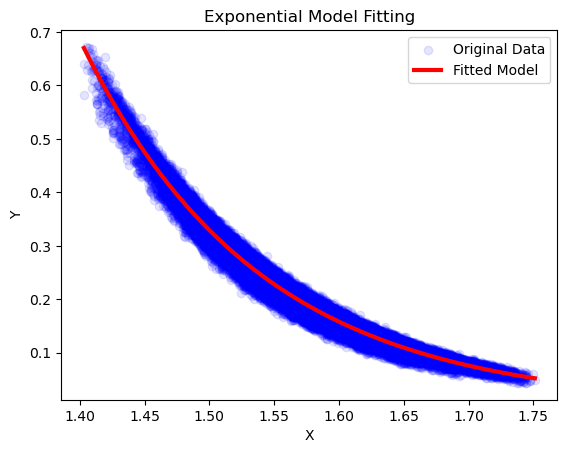

In [9]:
import matplotlib.pyplot as plt

# Generate predictions from the model
with torch.no_grad():  # We don't need gradients for prediction
    predicted = torch.exp(model(X_torch)).numpy()

# Plotting the original data
plt.scatter(X, Y, color="blue", label="Original Data", alpha=0.1)

# Plotting the model's predictions
plt.plot(X, predicted, color="red", label="Fitted Model", linewidth=3)

# Adding labels and title
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Exponential Model Fitting")
plt.legend()
# plt.yscale("log")

Text(0.5, 1.0, 'Histogram of Residuals')

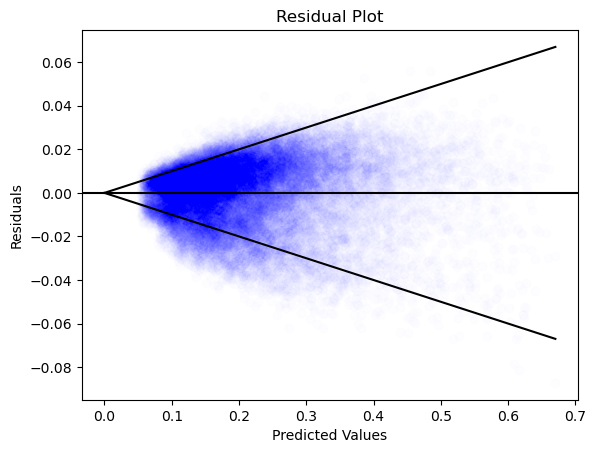

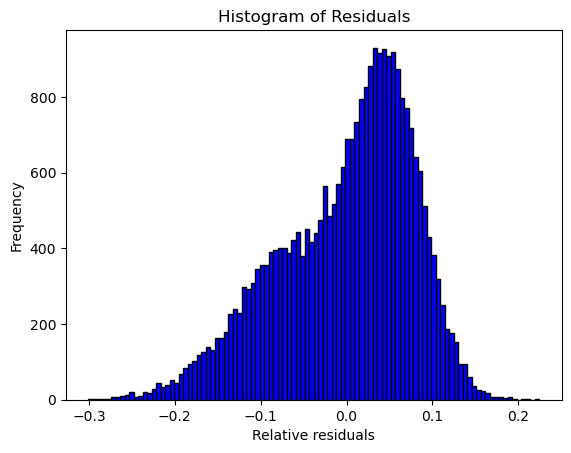

In [10]:
import matplotlib.pyplot as plt


# Function to calculate residuals
def calculate_residuals(model, X, Y):
    model.eval()  # Set the model to evaluation mode
    with torch.no_grad():
        predictions = torch.exp(model(X))
    residuals = Y - predictions
    return predictions, residuals


# Calculate residuals
predictions, residuals = calculate_residuals(model, X_torch, Y_torch)

# Convert to numpy for plotting
predictions_np = predictions.numpy().flatten()
residuals_np = residuals.numpy().flatten()

# Plotting residuals
plt.figure()
plt.scatter(predictions_np, residuals_np, color="blue", alpha=8e-3)
plt.axhline(y=0, color="k", linestyle="-")
x = np.linspace(0, np.max(predictions_np), 100)
plt.plot(x, 0.1 * x, color="k")
plt.plot(x, -0.1 * x, color="k")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")

# Optional: Histogram of Residuals
plt.figure()
plt.hist(residuals_np / predictions_np, bins=100, color="blue", edgecolor="black")
plt.xlabel("Relative residuals")
plt.ylabel("Frequency")
plt.title("Histogram of Residuals")

## Fit with neighboring atom numbers as a descriptor

Identify neighboring atom numbers.

In [11]:
X = nnr[mask]
Y = nnt[mask]

In [12]:
def count_neighbors(grid_size, edges):
    grid_width, grid_height = grid_size

    # Helper function to get the row and column from vertex index
    def get_row_col(vertex, width):
        return vertex // width, vertex % width

    # Initialize the count array
    neighbor_counts = []

    for edge in edges:
        count = 0

        # Get row and column for both vertices
        row, col = get_row_col(edge, grid_width)

        # Determine the edge orientation and count neighbors
        if np.diff(row):  # Horizontal edge
            # Check left and right neighbors
            row = np.sort(row)
            count += 1 if row[0] > 0 else 0
            count += 1 if row[1] < grid_height - 1 else 0
        elif np.diff(col):  # Vertical edge
            # Check top and bottom neighbors
            col = np.sort(col)
            count += 1 if col[0] > 0 else 0
            count += 1 if col[1] < grid_width - 1 else 0
        neighbor_counts.append(count)

    return neighbor_counts


# Example Usage
grid = [4, 4]
edges = links

neighbor_counts = np.array(count_neighbors(grid, edges))
for i in range(len(edges)):
    print(f"Edge {i}: {edges[i]} descriptor: {neighbor_counts[i]}")

Edge 0: [0 1] descriptor: 1
Edge 1: [1 2] descriptor: 2
Edge 2: [2 3] descriptor: 1
Edge 3: [0 4] descriptor: 1
Edge 4: [1 5] descriptor: 1
Edge 5: [4 5] descriptor: 1
Edge 6: [2 6] descriptor: 1
Edge 7: [5 6] descriptor: 2
Edge 8: [3 7] descriptor: 1
Edge 9: [6 7] descriptor: 1
Edge 10: [4 8] descriptor: 2
Edge 11: [5 9] descriptor: 2
Edge 12: [8 9] descriptor: 1
Edge 13: [ 6 10] descriptor: 2
Edge 14: [ 9 10] descriptor: 2
Edge 15: [ 7 11] descriptor: 2
Edge 16: [10 11] descriptor: 1
Edge 17: [ 8 12] descriptor: 1
Edge 18: [ 9 13] descriptor: 1
Edge 19: [12 13] descriptor: 1
Edge 20: [10 14] descriptor: 1
Edge 21: [13 14] descriptor: 2
Edge 22: [11 15] descriptor: 1
Edge 23: [14 15] descriptor: 1


Goal: write down the model s.t. input also takes descriptor. For example, 
$$ Y(X, d) = b(d) * exp(a(d) * X(d)) $$
and $b(d) = c_1 * d + c_2$ and $a(d) = c_3 * d + c_4$.

$d$ can be meshgrid like X. But it's better to be stored in a 1D array.

In [16]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.autograd import Variable

l = X.shape[1]


# Custom Model for Exponential Fitting
class ExponentialModel(nn.Module):
    def __init__(self):
        super(ExponentialModel, self).__init__()
        self.a = nn.Parameter(torch.randn((2,)))  # Initialize the 'a' parameter
        self.b = nn.Parameter(torch.randn((2,)))  # Initialize the 'b' parameter

    def forward(self, x):
        a = self.a[0] * x["d"][None] + self.a[1]
        b = self.b[0] * x["d"][None] + self.b[1]
        return b * torch.exp(a * x["rij"])


# Convert data to torch tensors
X_torch = {}
X_torch["rij"] = torch.tensor(X, dtype=torch.float64)
X_torch["d"] = torch.tensor(neighbor_counts, dtype=torch.float64)
Y_torch = torch.tensor(Y, dtype=torch.float64)

# Initialize the model
model = ExponentialModel()


def criterion(outputs, targets):
    # Define the MSE loss
    mse_loss = nn.MSELoss()

    # Inside your training loop
    loss = mse_loss(outputs, targets) / (
        torch.var(targets) if torch.var(targets) != 0 else 1.0
    )
    return loss


def regression(X, Y, model: nn.Module, maxiter=1000, tol=1e-9):
    # optimizer = optim.SGD(model.parameters(), lr=0.01)
    # Using L-BFGS Optimizer
    optimizer = optim.LBFGS(
        model.parameters(),
        lr=0.005,
        max_iter=maxiter,
        tolerance_grad=tol * 1e2,
        tolerance_change=tol,
    )

    # Training Loop
    loss_old = torch.inf
    loss_new = torch.inf

    def closure():
        optimizer.zero_grad()
        outputs = model(X)
        loss = criterion(outputs, Y)
        loss.backward()
        return loss

    # Training Loop
    for epoch in range(maxiter):  # Number of epochs
        if loss_old - loss_new < tol:
            break
        loss_old = loss_new

        optimizer.step(closure)
        loss = closure().item()
        loss_new = loss
        # # Forward pass
        # outputs = model(X_torch)
        # loss = criterion(outputs, Y_torch)
        # loss_new = loss.item()
        if epoch % 1 == 0:
            outputs = model(X)
            print(Y - outputs)
            print(f"Epoch [{epoch+1}/{maxiter}], Loss: {loss_new:.4f}")
        # # Backward and optimize
        # optimizer.zero_grad()
        # loss.backward()
        # optimizer.step()

    print(f"Final Loss: {loss_new:.4f}")
    return model


def r_squared(X, Y, model: nn.Module):
    # Step 1: Predict Outputs
    model.eval()  # Set the model to evaluation mode
    with torch.no_grad():
        predictions = model(X)

    # Step 2: Calculate SST
    sst = torch.std(Y) ** 2
    # Step 3: Calculate SSR
    ssr = torch.mean((Y - predictions) ** 2)

    # Step 4: Compute R^2
    r2 = 1 - ssr / sst
    return r2.item()


model = regression(X_torch, Y_torch, model)
r2 = r_squared(X_torch, Y_torch, model)

a = model.a
b = model.b

print(f"Exponential model: Y = ({b[0]} * d + {b[1]}) * exp(({a[0]} * d + {a[1]}) * X)")
print(f"R^2 Score: {r2}")

tensor([[-0.3640,  4.5608, -0.4009,  ...,  4.3135, -0.5116, -0.2828],
        [-0.2140,  4.3791, -0.3873,  ...,  3.9314, -0.3153, -0.5920],
        [-0.4238,  4.5076, -0.2176,  ...,  4.0368, -0.2576, -0.5769],
        ...,
        [-0.4435,  4.4090, -0.4718,  ...,  4.5161, -0.4457, -0.3101],
        [-0.4652,  4.2029, -0.5417,  ...,  3.9825, -0.5286, -0.4538],
        [-0.3132,  4.5557, -0.3260,  ...,  4.0654, -0.5297, -0.4972]],
       dtype=torch.float64, grad_fn=<SubBackward0>)
Epoch [1/1000], Loss: 559.4594
tensor([[ 0.0297,  0.1194, -0.0039,  ...,  0.1607, -0.1045,  0.1062],
        [ 0.1703,  0.1314,  0.0071,  ...,  0.3266,  0.0756, -0.1750],
        [-0.0254,  0.1189,  0.1676,  ...,  0.2723,  0.1283, -0.1617],
        ...,
        [-0.0434,  0.1512, -0.0692,  ...,  0.1201, -0.0469,  0.0805],
        [-0.0629,  0.1974, -0.1316,  ...,  0.2931, -0.1199, -0.0530],
        [ 0.0765,  0.1114,  0.0650,  ...,  0.2410, -0.1213, -0.0926]],
       dtype=torch.float64, grad_fn=<SubBackward0

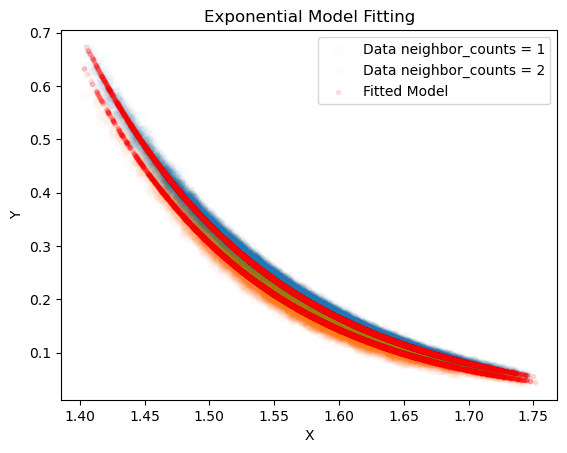

In [17]:
import matplotlib.pyplot as plt

# Generate predictions from the model
with torch.no_grad():  # We don't need gradients for prediction
    predicted = model(X_torch).numpy()

# Plotting the original data
for i in [1, 2]:
    plt.scatter(
        X[:, neighbor_counts == i],
        Y[:, neighbor_counts == i],
        label="Data neighbor_counts = " + str(i),
        alpha=1e-2,
    )

# Plotting the model's predictions
plt.scatter(X, predicted, color="red", label="Fitted Model", marker=".", alpha=0.1)

# Adding labels and title
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Exponential Model Fitting")
plt.legend()

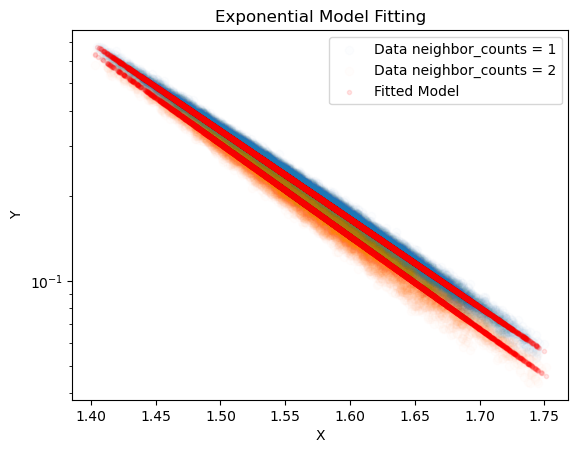

In [18]:
import matplotlib.pyplot as plt

# Generate predictions from the model
with torch.no_grad():  # We don't need gradients for prediction
    predicted = model(X_torch).numpy()

for i in [1, 2]:
    plt.scatter(
        X[:, neighbor_counts == i],
        Y[:, neighbor_counts == i],
        label="Data neighbor_counts = " + str(i),
        alpha=1e-2,
    )

# Plotting the model's predictions
plt.scatter(X, predicted, color="red", label="Fitted Model", marker=".", alpha=0.1)

# Adding labels and title
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Exponential Model Fitting")
plt.legend()
plt.yscale("log")

Text(0.5, 1.0, 'Histogram of Residuals')

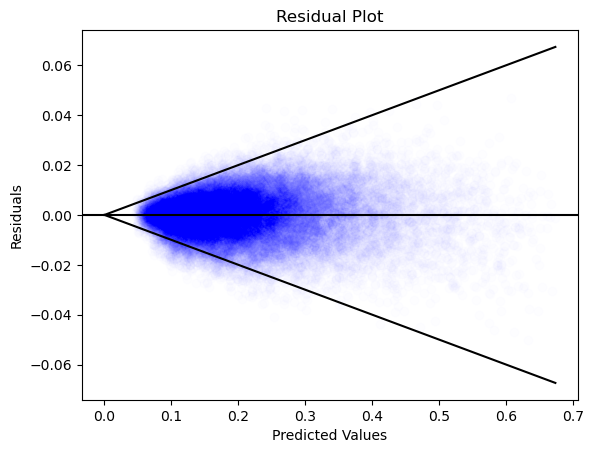

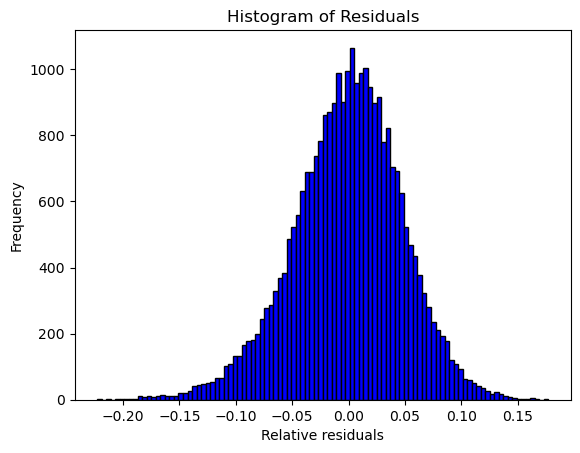

In [19]:
import matplotlib.pyplot as plt


# Function to calculate residuals
def calculate_residuals(model, X, Y):
    model.eval()  # Set the model to evaluation mode
    with torch.no_grad():
        predictions = model(X)
    residuals = Y - predictions
    return predictions, residuals


# Calculate residuals
predictions, residuals = calculate_residuals(model, X_torch, Y_torch)

# Convert to numpy for plotting
predictions_np = predictions.numpy()
residuals_np = residuals.numpy()
sigma = np.std(residuals_np)

# Plotting residuals
plt.figure()
for i in [1, 2]:
    plt.scatter(
        predictions_np[:, neighbor_counts == i],
        residuals_np[:, neighbor_counts == i],
        color="blue",
        alpha=8e-3,
    )
plt.axhline(y=0, color="k", linestyle="-")
x = np.linspace(0, np.max(predictions_np), 100)
plt.plot(x, 0.1 * x, color="k")
plt.plot(x, -0.1 * x, color="k")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")

# Optional: Histogram of Residuals
plt.figure()
plt.hist(
    residuals_np.flatten() / abs(predictions_np.flatten()),
    bins=100,
    color="blue",
    edgecolor="black",
)
plt.xlabel("Relative residuals")
plt.ylabel("Frequency")
plt.title("Histogram of Residuals")

# Optional: Histogram of Residuals ratio to sigma
plt.figure()
plt.hist(residuals_np.flatten() / sigma, bins=100, color="blue", edgecolor="black")
plt.xlabel("Residuals ($\sigma$)")
plt.ylabel("Frequency (kHz)")
plt.title(f"Histogram of Residuals in unit of $\sigma$={sigma}kHz")

Max fitting residual scales ~10% of the data. And R2 means the overall fitting residual is smaller.